In [3]:
import pandas as pd

df = pd.read_csv('datasets/spotify_songs_2015_2025.csv')

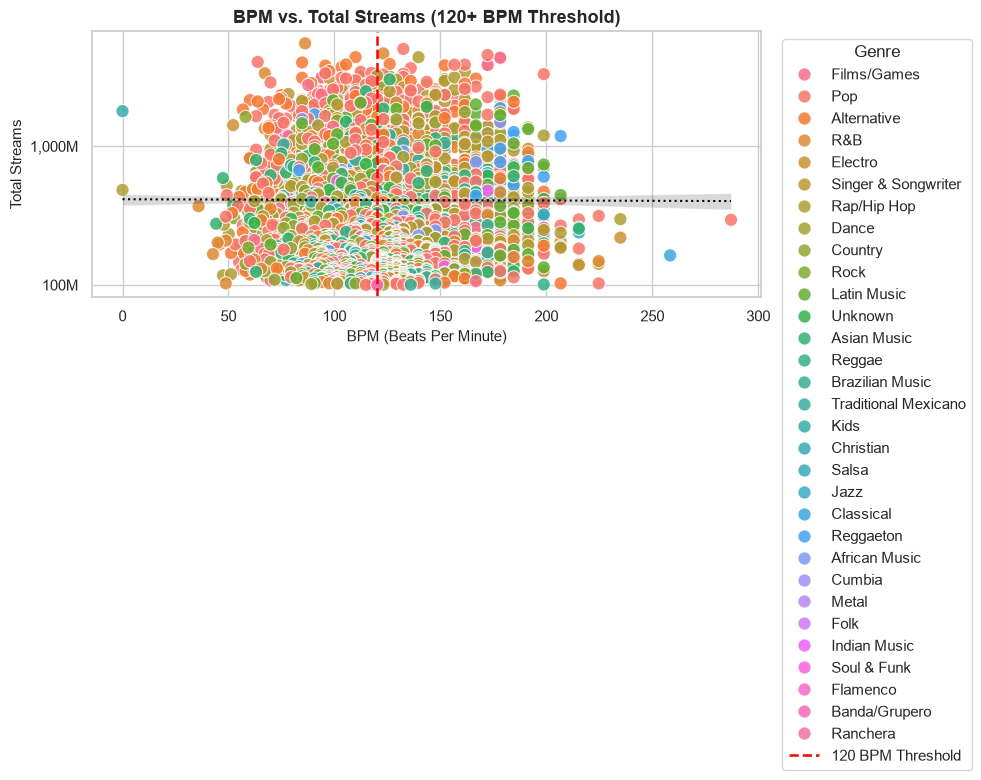

Pearson Correlation (BPM vs Streams): -0.0027
Average Streams (< 120 BPM):  416,636,609
Average Streams (>= 120 BPM): 404,025,634


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

master_df = pd.read_csv("datasets/bpm_counted.csv")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

#Scatter plot of BPM vs Streams
sns.scatterplot(
    data=master_df,
    x="BPM",
    y="Streams",
    hue="Genre",
    alpha=0.85,
    s=90,
)

#120 BPM threshold line
plt.axvline(
    120,
    color="red",
    linestyle="--",
    linewidth=1.8,
    label="120 BPM Threshold",
)

#Overall trendline
sns.regplot(
    data=master_df,
    x="BPM",
    y="Streams",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1.5, "linestyle": ":"},
)
plt.yscale("log")
plt.title(
    "BPM vs. Total Streams (120+ BPM Threshold)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("BPM (Beats Per Minute)", fontsize=11)
plt.ylabel("Total Streams", fontsize=11)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"{x*1e-6:,.0f}M")
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Genre")

plt.tight_layout()
plt.savefig("bpm_total_streams.png", dpi=300, bbox_inches="tight")
plt.show()

#Statistical verification
bpm_corr = master_df["BPM"].corr(master_df["Streams"])
under_120 = master_df[master_df["BPM"] < 120]["Streams"].mean()
over_120 = master_df[master_df["BPM"] >= 120]["Streams"].mean()

print(f"Pearson Correlation (BPM vs Streams): {bpm_corr:.4f}")
print(f"Average Streams (< 120 BPM):  {under_120:,.0f}")
print(f"Average Streams (>= 120 BPM): {over_120:,.0f}")

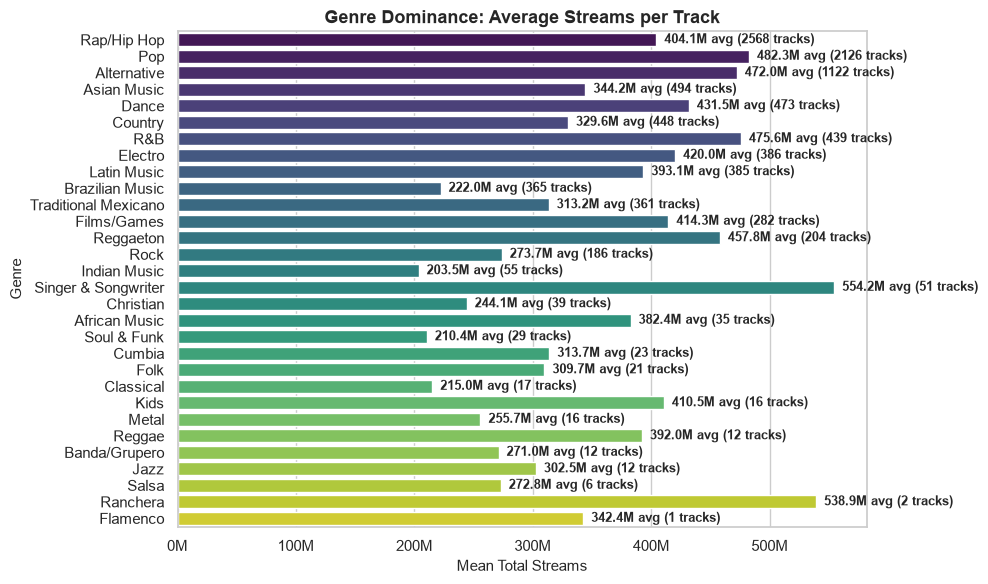

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

#Aggregate and sort by track 'count'
genre_stats = (
    master_df[master_df["Genre"] != "Unknown"]
    .groupby("Genre")["Streams"]
    .agg(["mean", "sum", "count"])
    .reset_index()
    .sort_values(by="count", ascending=False)
)

ax = sns.barplot(
    data=genre_stats, 
    x="mean", 
    y="Genre", 
    hue="Genre", 
    palette="viridis", 
    legend=False
)

for index, row in enumerate(genre_stats.itertuples()):
    ax.text(
        row.mean,
        index,
        f"  {row.mean/1e6:,.1f}M avg ({row.count} tracks)",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

plt.title(
    "Genre Dominance: Average Streams per Track",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Mean Total Streams", fontsize=11)
plt.ylabel("Genre", fontsize=11)
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"{x*1e-6:,.0f}M")
)

plt.tight_layout()
plt.savefig("genre_dominance.png", dpi=300, bbox_inches="tight")
plt.show()

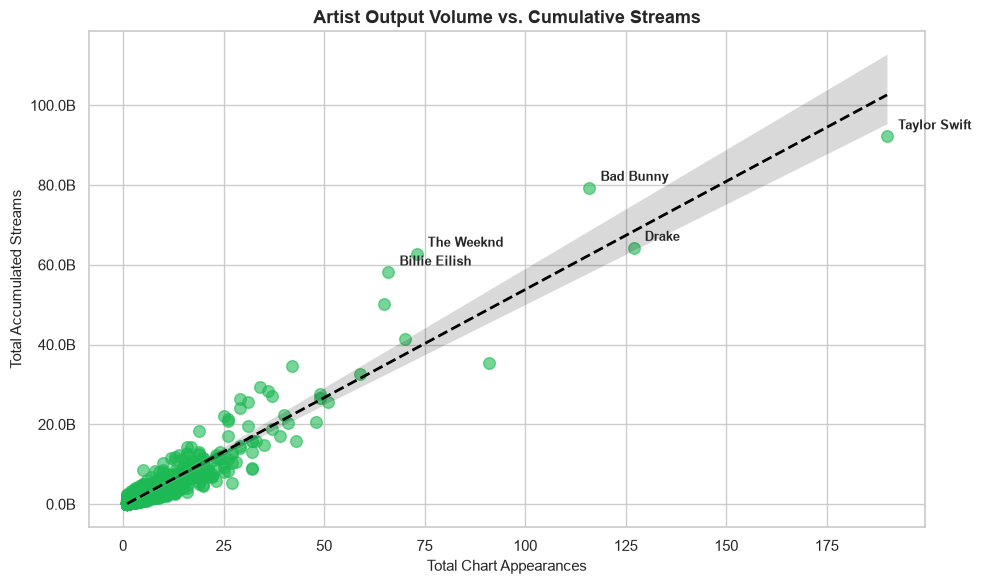

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datasets/bpm_counted.csv")

sns.set_theme(style="whitegrid")

#Aggregate dataset
artist_perf = (
    df.groupby("Artist")
    .agg(Appearances=("Track", "count"), Total_Streams=("Streams", "sum"))
    .reset_index()
)

plt.figure(figsize=(10, 6))

#Plot scatter with regression trendline
sns.regplot(
    data=artist_perf,
    x="Appearances",
    y="Total_Streams",
    scatter_kws={"alpha": 0.6, "s": 70, "color": "#1DB954"},
    line_kws={"color": "black", "linestyle": "--", "linewidth": 2},
)

#Label top 5 artists with highest streams
top_artists = artist_perf.nlargest(5, "Total_Streams")
for _, row in top_artists.iterrows():
  plt.annotate(
      row["Artist"],
      (row["Appearances"], row["Total_Streams"]),
      xytext=(8, 5),
      textcoords="offset points",
      fontsize=9,
      fontweight="bold",
  )

plt.title(
    "Artist Output Volume vs. Cumulative Streams", fontsize=13, fontweight="bold"
)
plt.xlabel("Total Chart Appearances", fontsize=11)
plt.ylabel("Total Accumulated Streams", fontsize=11)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"{x*1e-9:,.1f}B")
)

plt.tight_layout()
plt.savefig("artists_volume.png", dpi=300, bbox_inches="tight")
plt.show()

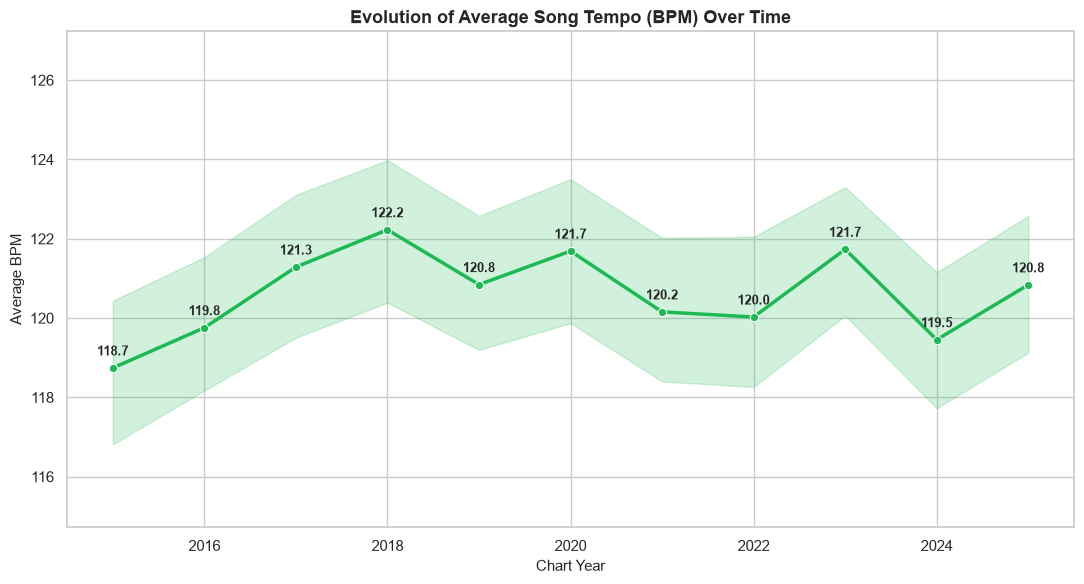

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

master_df = pd.read_csv("datasets/bpm_counted.csv")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

ax = sns.lineplot(
    data=master_df,
    x="Chart Year",
    y="BPM",
    marker="o",
    linewidth=2.5,
    color="#1DB954",
    errorbar=("ci", 95),  # 95% confidence interval across all songs
)

#Annotate mean values
yearly_means = master_df.groupby("Chart Year")["BPM"].mean()
for year, mean_val in yearly_means.items():
  if pd.notna(mean_val):
    ax.annotate(
        f"{mean_val:.1f}",
        (year, mean_val),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

#Zoom Y-axis around the yearly averages for clear visibility
plt.ylim(yearly_means.min() - 4, yearly_means.max() + 5)

plt.title(
    "Evolution of Average Song Tempo (BPM) Over Time",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Chart Year", fontsize=11)
plt.ylabel("Average BPM", fontsize=11)

plt.tight_layout()
plt.savefig("bpm_overtime.png", dpi=300, bbox_inches="tight")
plt.show()

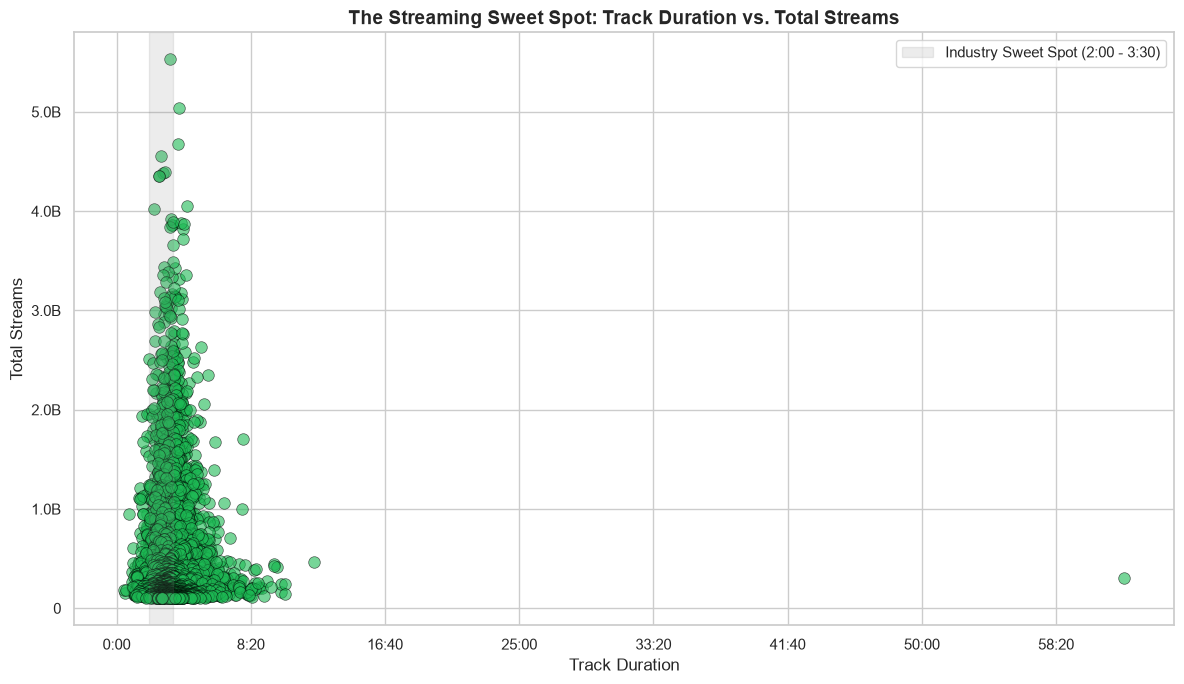

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

master_df = pd.read_csv("datasets/bpm_counted.csv")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=master_df,
    x="Duration (s)",
    y="Streams",
    alpha=0.6,
    color="#1DB954",  # A nice Spotify Green
    edgecolor="black",
    linewidth=0.5,
    s=70
)

plt.axvspan(
    120, 210, 
    color='gray', 
    alpha=0.15, 
    label="Industry Sweet Spot (2:00 - 3:30)"
)

#Format the X-axis to show Minutes:Seconds
def seconds_to_mins(x, pos):
    minutes = int(x // 60)
    seconds = int(x % 60)
    return f"{minutes}:{seconds:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(seconds_to_mins))

#Format the Y-axis to show Millions (M) and Billions (B)
def format_streams(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.0f}M'
    return f'{x:.0f}'

ax.yaxis.set_major_formatter(FuncFormatter(format_streams))

plt.title(
    "The Streaming Sweet Spot: Track Duration vs. Total Streams", 
    fontsize=14, 
    fontweight="bold"
)
plt.xlabel("Track Duration", fontsize=12)
plt.ylabel("Total Streams", fontsize=12)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("duration_vs_streams.png", dpi=300, bbox_inches="tight")
plt.show()

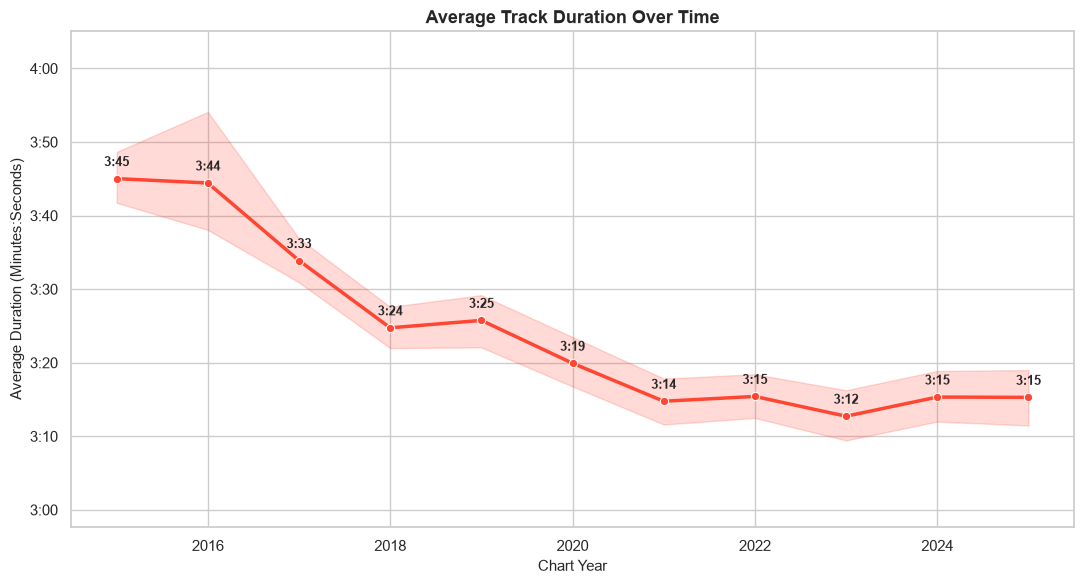

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

master_df = pd.read_csv("datasets/bpm_counted.csv")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

#Plot the mean duration by year
ax = sns.lineplot(
    data=master_df,
    x="Chart Year",
    y="Duration (s)",
    marker="o",
    linewidth=2.5,
    color="#FF4633", 
    errorbar=("ci", 95),
)

#Format the Y-axis to show Minutes:Seconds instead of raw seconds
def seconds_to_mins(x, pos):
    minutes = int(x // 60)
    seconds = int(x % 60)
    return f"{minutes}:{seconds:02d}"

ax.yaxis.set_major_formatter(FuncFormatter(seconds_to_mins))

#Annotate each point with the exact MM:SS
yearly_durations = master_df.groupby("Chart Year")["Duration (s)"].mean()
for year, mean_sec in yearly_durations.items():
    if pd.notna(mean_sec):
        mins = int(mean_sec // 60)
        secs = int(mean_sec % 60)
        time_str = f"{mins}:{secs:02d}"
        
        ax.annotate(
            time_str,
            (year, mean_sec),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

#Zoom Y-axis around the data for better visibility
plt.ylim(yearly_durations.min() - 15, yearly_durations.max() + 20)

plt.title(
    "Average Track Duration Over Time",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Chart Year", fontsize=11)
plt.ylabel("Average Duration (Minutes:Seconds)", fontsize=11)

plt.tight_layout()

plt.savefig("duration_over_time.png", dpi=300, bbox_inches="tight")
plt.show()